# 04 TrAISformer Exact Replication (Region 1)

This notebook replicates the **actual** `CEE_TrAISformer/trAISformer.py` pipeline:
- Build TrAISformer `*.pkl` trajectory files from `region_1_interpolated.parquet`
- Train using `CEE_TrAISformer/models.py`, `datasets.py`, `trainers.py`
- Inspect logits, CE loss components, and sampling behavior

Important: `region_1_dense_embeddings.h5` is kept only for diagnostics and visualization. It is **not** used by the original TrAISformer training path.

In [1]:
from pathlib import Path
import os, sys, json, pickle, subprocess
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

ROOT = Path('/home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_')
NOTEBOOK_DIR = ROOT / 'CEE-Replication' / 'Notebook'
TRAISFORMER_DIR = ROOT / 'CEE_TrAISformer'
REGION_DATA_DIR = ROOT / 'CEE-Replication' / 'traisformer_data' / 'region_1'

assert TRAISFORMER_DIR.exists(), TRAISFORMER_DIR
sys.path.insert(0, str(TRAISFORMER_DIR))
print('Using repo:', ROOT)
print('Using TrAISformer src:', TRAISFORMER_DIR)

/home/crimsondeepdarshak/Desktop/Deep_Darshak/code_/env/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using repo: /home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_
Using TrAISformer src: /home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_/CEE_TrAISformer


## 1) Build TrAISformer-Compatible Dataset (`*.pkl`)

This step converts Region 1 parquet rows into trajectory windows with the same shape expected by `AISDataset`:
- each sample: `{'mmsi': int, 'traj': np.ndarray[N,6]}`
- traj columns: `[lat_norm, lon_norm, sog_norm, cog_norm, unix_time, mmsi]`

In [2]:
builder = NOTEBOOK_DIR / 'build_region1_traisformer_dataset.py'
assert builder.exists(), builder

train_pkl = REGION_DATA_DIR / 'region_1_train.pkl'
valid_pkl = REGION_DATA_DIR / 'region_1_valid.pkl'
test_pkl = REGION_DATA_DIR / 'region_1_test.pkl'

if not (train_pkl.exists() and valid_pkl.exists() and test_pkl.exists()):
    cmd = [
        sys.executable,
        str(builder),
        '--input', str(NOTEBOOK_DIR / 'region_1_interpolated.parquet'),
        '--outdir', str(REGION_DATA_DIR),
        '--max-seqlen-plus-one', '121',
        '--min-seqlen', '37',
        '--stride', '60',
        '--max-sog', '30.0',
        '--seed', '42',
    ]
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True)
else:
    print('Pickles already exist. Skipping rebuild.')

meta = json.loads((REGION_DATA_DIR / 'metadata.json').read_text())
print(json.dumps(meta['splits'], indent=2))
print('Normalization:', json.dumps(meta['normalization'], indent=2))

Pickles already exist. Skipping rebuild.
{
  "train_windows": 377476,
  "valid_windows": 45118,
  "test_windows": 45984,
  "train_mmsi": 12511,
  "valid_mmsi": 1563,
  "test_mmsi": 1565
}
Normalization: {
  "lat_min": 17.444502113282542,
  "lat_max": 31.10030578215527,
  "lon_min": -98.73875593375215,
  "lon_max": -80.20286521880064,
  "max_sog": 30.0,
  "cog_divisor": 360.0,
  "clip_max": 0.9999
}


In [3]:
with open(train_pkl, 'rb') as f:
    train_raw = pickle.load(f)
with open(valid_pkl, 'rb') as f:
    valid_raw = pickle.load(f)
with open(test_pkl, 'rb') as f:
    test_raw = pickle.load(f)

print('train/valid/test windows:', len(train_raw), len(valid_raw), len(test_raw))
ex = train_raw[0]
print('sample keys:', ex.keys())
print('sample traj shape:', ex['traj'].shape)
print('first row [lat,lon,sog,cog,t,mmsi]:', ex['traj'][0])

train/valid/test windows: 377476 45118 45984
sample keys: dict_keys(['mmsi', 'traj'])
sample traj shape: (121, 6)
first row [lat,lon,sog,cog,t,mmsi]: [9.46110401e-01 5.20705807e-01 0.00000000e+00 8.69722222e-01
 1.73568900e+06 1.03669999e+08]


## 2) Optional H5 Diagnostics

The generated H5 stores dense vectors (`[N,256]`) from a separate embedding notebook.
We inspect it here, but **do not feed it into the exact TrAISformer model**.

In [6]:
import h5py
h5_path = NOTEBOOK_DIR / 'region_1_dense_embeddings.h5'
if h5_path.exists():
    with h5py.File(h5_path, 'r') as f:
        keys = list(f.keys())
        print('H5 keys:', keys)
        d = f[keys[0]]
        print('H5 shape:', d.shape, 'dtype:', d.dtype)
        print('first vector first 256 dims:', d[0, :])
else:
    print('H5 file not found:', h5_path)

H5 keys: ['embeddings']
H5 shape: (28274619, 256) dtype: float32
first vector first 256 dims: [ 2.3784022e+00  6.1597958e-02  8.6635530e-01 -7.1558022e-01
  1.1282145e+00  1.3917862e+00  7.6406437e-01 -3.5190904e-01
 -1.6088928e+00 -1.1026379e+00  1.4445677e+00 -1.5292090e-01
  7.5834051e-02  4.9119976e-01  3.9525903e-03 -2.9729846e-01
  1.6507776e-01 -1.0427171e+00 -1.8986805e-01 -9.1230673e-01
  9.6040493e-01  9.8930061e-01  4.5390713e-01  1.0312573e+00
  4.9559885e-01  4.5970669e-01 -3.5345390e-01  6.2848337e-02
  7.1653113e-02 -2.7498606e-01 -8.7672770e-01 -6.2025058e-01
  1.0751262e+00  9.0101683e-01  4.3285653e-01  7.5919223e-01
  1.8325081e+00  2.9734698e-01  9.2417026e-01  4.1128695e-01
  1.1781223e+00 -9.5024562e-01 -4.2220306e-01 -4.5471799e-01
 -2.5753686e+00 -1.1310973e+00  5.1451790e-01 -4.1695970e-01
 -1.5413857e+00 -7.5160772e-01  7.7793783e-01 -2.5311020e-01
  5.0406712e-01 -1.9644421e-01  1.7079846e+00  4.5120469e-01
  1.8656645e+00 -8.4163964e-01  7.4527544e-01 -3.250

## 3) Load Original TrAISformer Modules and Config

In [7]:
import datasets, models, trainers

class RegionConfig:
    # runtime
    retrain = True
    tb_log = False
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    # optimization (same style as original config)
    max_epochs = 10
    batch_size = 32
    n_samples = 8
    learning_rate = 6e-4
    betas = (0.9, 0.95)
    grad_norm_clip = 1.0
    weight_decay = 0.1
    lr_decay = True
    warmup_tokens = 512 * 20
    final_tokens = 260e9
    num_workers = 0

    # sequence settings
    init_seqlen = 18
    max_seqlen = 120
    min_seqlen = 36

    # model/sampling flags
    mode = 'pos'
    sample_mode = 'pos_vicinity'
    top_k = 10
    r_vicinity = 40

    # blur regularization (this is the modified loss in code)
    blur = True
    blur_learnable = False
    blur_loss_w = 1.0
    blur_n = 2

    # region normalization bounds from metadata
    lat_min = meta['normalization']['lat_min']
    lat_max = meta['normalization']['lat_max']
    lon_min = meta['normalization']['lon_min']
    lon_max = meta['normalization']['lon_max']

    # classification sizes (keep original TrAISformer defaults)
    lat_size = 250
    lon_size = 270
    sog_size = 30
    cog_size = 72

    # embedding dims / transformer depth
    n_lat_embd = 256
    n_lon_embd = 256
    n_sog_embd = 128
    n_cog_embd = 128
    n_head = 8
    n_layer = 8
    embd_pdrop = 0.1
    resid_pdrop = 0.1
    attn_pdrop = 0.1

    dataset_name = 'region_1'
    full_size = lat_size + lon_size + sog_size + cog_size
    n_embd = n_lat_embd + n_lon_embd + n_sog_embd + n_cog_embd

    savedir = str(ROOT / 'CEE-Replication' / 'results' / 'region_1_trAISformer') + '/'
    ckpt_path = os.path.join(savedir, 'model.pt')

cf = RegionConfig()
os.makedirs(cf.savedir, exist_ok=True)
print('Device:', cf.device)
print('Checkpoint:', cf.ckpt_path)

Device: cuda:0
Checkpoint: /home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_/CEE-Replication/results/region_1_trAISformer/model.pt


## 4) Build AISDataset and Visualize Input

In [8]:
train_ds = datasets.AISDataset(train_raw, max_seqlen=cf.max_seqlen + 1, device=cf.device)
valid_ds = datasets.AISDataset(valid_raw, max_seqlen=cf.max_seqlen + 1, device=cf.device)
test_ds = datasets.AISDataset(test_raw, max_seqlen=cf.max_seqlen + 1, device=cf.device)
print('Dataset lens:', len(train_ds), len(valid_ds), len(test_ds))

seq, mask, seqlen, mmsi, t0 = train_ds[0]
print('seq shape:', seq.shape, 'mask shape:', mask.shape, 'seqlen:', int(seqlen))
print('mmsi:', int(mmsi), 'time_start_unix:', int(t0))
print('first 3 normalized rows:\n', seq[:3])

Dataset lens: 377476 45118 45984
seq shape: torch.Size([121, 4]) mask shape: torch.Size([121]) seqlen: 121
mmsi: 103669999 time_start_unix: 1735689
first 3 normalized rows:
 tensor([[9.4611e-01, 5.2071e-01, 0.0000e+00, 8.6972e-01],
        [9.4610e-01, 5.2070e-01, 7.1685e-05, 8.6954e-01],
        [9.4609e-01, 5.2069e-01, 1.4337e-04, 8.6936e-01]])


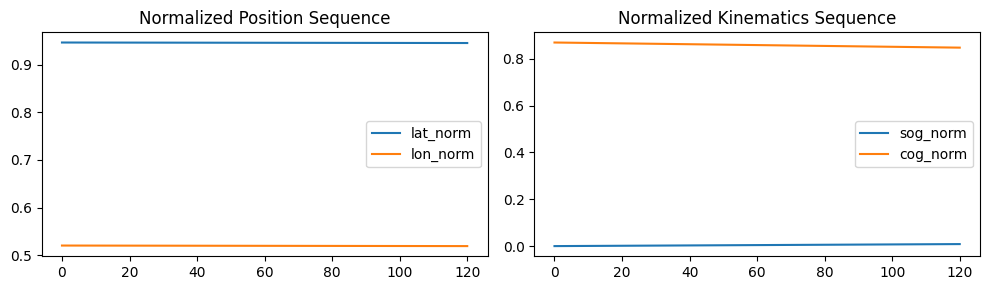

In [9]:
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(seq[:int(seqlen), 0].numpy(), label='lat_norm')
plt.plot(seq[:int(seqlen), 1].numpy(), label='lon_norm')
plt.legend()
plt.title('Normalized Position Sequence')

plt.subplot(1, 2, 2)
plt.plot(seq[:int(seqlen), 2].numpy(), label='sog_norm')
plt.plot(seq[:int(seqlen), 3].numpy(), label='cog_norm')
plt.legend()
plt.title('Normalized Kinematics Sequence')
plt.tight_layout()
plt.show()

## 5) Instantiate Real TrAISformer and Inspect Forward + Loss

In [10]:
model = models.TrAISformer(cf, partition_model=None).to(cf.device)
print('n_params:', sum(p.numel() for p in model.parameters()))

loader = DataLoader(train_ds, batch_size=cf.batch_size, shuffle=True)
seqs, masks, seqlens, mmsis, tstarts = next(iter(loader))
seqs = seqs.to(cf.device)
masks = masks[:, :-1].to(cf.device)

logits, loss, loss_tuple = model(seqs, masks=masks, with_targets=True, return_loss_tuple=True)
print('logits shape:', tuple(logits.shape))
print('loss:', float(loss))
print('loss tuple shapes:', [tuple(x.shape) for x in loss_tuple])
print('mean per-head CE:')
print('  lat:', float(loss_tuple[0].mean()))
print('  lon:', float(loss_tuple[1].mean()))
print('  sog:', float(loss_tuple[2].mean()))
print('  cog:', float(loss_tuple[3].mean()))

n_params: 57420547
logits shape: (32, 120, 622)
loss: 19.421775817871094
loss tuple shapes: [(32, 120), (32, 120), (32, 120), (32, 120)]
mean per-head CE:
  lat: 5.72585391998291
  lon: 5.744292259216309
  sog: 3.4498801231384277
  cog: 4.500209808349609


/tmp/ipykernel_9717/2632663533.py:11: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('loss:', float(loss))


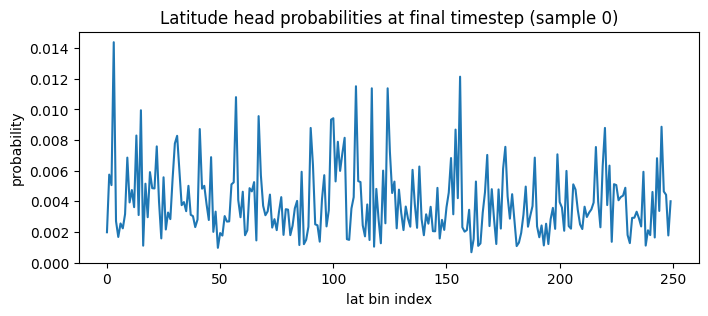

In [11]:
lat_logits, lon_logits, sog_logits, cog_logits = torch.split(
    logits[:, :, :],
    (cf.lat_size, cf.lon_size, cf.sog_size, cf.cog_size),
    dim=-1
)
last_lat_probs = torch.softmax(lat_logits[0, -1], dim=-1).detach().cpu().numpy()
plt.figure(figsize=(8, 3))
plt.plot(last_lat_probs)
plt.title('Latitude head probabilities at final timestep (sample 0)')
plt.xlabel('lat bin index')
plt.ylabel('probability')
plt.show()

## 6) Train with Original Trainer (same path as `trAISformer.py`)

In [ ]:
trainer = trainers.Trainer(
    model=model,
    train_dataset=train_ds,
    test_dataset=valid_ds,
    config=cf,
    savedir=cf.savedir,
    device=cf.device,
    aisdls={},
    INIT_SEQLEN=cf.init_seqlen,
)

RUN_TRAIN = True # change to True to run full training
if RUN_TRAIN:
    trainer.train()
    print('Training completed.')
else:
    print('Training skipped. Set RUN_TRAIN=True to train.')

epoch 1 iter 590: loss -2.04950. lr 6.000000e-04:   5%|▌         | 591/11797 [01:09<21:53,  8.53it/s]

## 7) Sampling Demo (Autoregressive Rollout)

In [ ]:
model.eval()
demo_batch = next(iter(DataLoader(test_ds, batch_size=4, shuffle=True)))
demo_seqs, demo_masks, demo_seqlens, demo_mmsis, demo_ts = demo_batch
demo_init = demo_seqs[:, :cf.init_seqlen, :].to(cf.device)

with torch.no_grad():
    preds = trainers.sample(
        model,
        demo_init,
        steps=12,
        temperature=1.0,
        sample=True,
        sample_mode=cf.sample_mode,
        r_vicinity=cf.r_vicinity,
        top_k=cf.top_k,
    )

print('init shape:', tuple(demo_init.shape), 'pred shape:', tuple(preds.shape))
print('first trajectory last predicted point [lat,lon,sog,cog]:', preds[0, -1].detach().cpu().numpy())

In [ ]:
p = preds[0].detach().cpu().numpy()
plt.figure(figsize=(5, 5))
plt.plot(p[:, 1], p[:, 0], marker='o', ms=2)
plt.title('Sampled normalized trajectory (lon vs lat)')
plt.xlabel('lon_norm')
plt.ylabel('lat_norm')
plt.grid(True)
plt.show()